# Installing Dependencies


In [1]:
%pip install tensorflow numpy pandas scikit-learn matplotlib pillow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Data Load


## ⚙️ Path Configuration

**Change `BASE_DIR` below to match where you extracted `img.zip`.**

Expected structure after extraction:
```
BASE_DIR/
  img/
    001bd5563b4511f0b16c00155d672fff.png
    ...
  train-label.csv
  test-label.csv
  submission.csv
```

In [2]:
import os
import numpy as np
import pandas as pd

BASE_DIR = '.'          # e.g. '/Users/yourname/Downloads/knu_ml'
IMG_DIR  = os.path.join(BASE_DIR, 'img')

TRAIN_LABEL = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'), index_col='id')
TEST_LABEL  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'),  index_col='id')

TRAIN_DATA = None
TEST_DATA  = None

print('Train samples:', len(TRAIN_LABEL))
print('Test  samples:', len(TEST_LABEL))
print('Label distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())

Train samples: 1385
Test  samples: 1386
Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64


# Do Your Own Jobs!

## 1. Imports & Reproducibility

In [3]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))
print('Metal (Apple Silicon) devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []
Metal (Apple Silicon) devices: []


## 2. Hyperparameters

In [4]:
# ── Image settings ───────────────────────────────────────────
# Larger input = more visual detail captured from memes
IMG_HEIGHT   = 160
IMG_WIDTH    = 160
IMG_CHANNELS = 3

# ── Training settings ────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 60
LR_INIT      = 1e-3
LR_WARMUP    = 5          # epochs of linear warm-up before cosine decay
WEIGHT_DECAY = 1e-4       # AdamW weight decay
LABEL_SMOOTH = 0.1        # label smoothing factor

# ── Augmentation settings ────────────────────────────────────
MIXUP_ALPHA  = 0.3        # Beta distribution alpha for MixUp
CUTMIX_ALPHA = 0.5        # Beta distribution alpha for CutMix
MIXUP_PROB   = 0.5        # probability of applying MixUp per batch
CUTMIX_PROB  = 0.5        # probability of applying CutMix per batch

# ── TTA settings ─────────────────────────────────────────────
TTA_STEPS    = 8          # number of augmented passes at inference

# ── Validation split ─────────────────────────────────────────
VAL_SPLIT    = 0.15

## 3. Image Loading

In [5]:
def load_image(filepath: str) -> np.ndarray:
    img = Image.open(filepath).convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0


def load_dataset(label_df, img_dir, has_labels=True):
    images, labels = [], []
    missing = 0
    for row_id, row in label_df.iterrows():
        path = os.path.join(img_dir, row['file'])
        if not os.path.exists(path):
            missing += 1
            continue
        images.append(load_image(path))
        if has_labels:
            labels.append(int(row['label']))
    if missing > 0:
        print(f'  ⚠️  {missing} images not found – skipped')
    X = np.stack(images).astype(np.float32)
    y = np.array(labels, dtype=np.int32) if has_labels else None
    return X, y


print('Loading train images …')
X_all, y_all = load_dataset(TRAIN_LABEL, IMG_DIR, has_labels=True)
print(f'  Train shape: {X_all.shape}, labels: {y_all.shape}')

print('Loading test images …')
X_test, _ = load_dataset(TEST_LABEL, IMG_DIR, has_labels=False)
print(f'  Test  shape: {X_test.shape}')

TRAIN_DATA = X_all
TEST_DATA  = X_test

Loading train images …
  Train shape: (1385, 160, 160, 3), labels: (1385,)
Loading test images …
  Test  shape: (1386, 160, 160, 3)


## 4. Train / Val Split

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_all
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}')

Train: (1177, 160, 160, 3)  Val: (208, 160, 160, 3)


## 5. Augmentation Pipeline: Base + MixUp + CutMix

**Why these techniques?**
- **Base augmentation**: flips, brightness/contrast, hue shift, random crop — makes the model robust to visual variation in meme images
- **Random Erasing**: masks a random rectangle, forces the model to learn distributed features rather than relying on a single region
- **MixUp**: linearly blends two images and their labels — proven to improve generalisation on small datasets (~1385 samples)
- **CutMix**: cuts a patch from one image and pastes onto another — better than MixUp for preserving local structure (important for meme text/characters)
- **Test-Time Augmentation (TTA)**: averages predictions across multiple augmented views at inference to reduce variance

In [7]:
AUTOTUNE = tf.data.AUTOTUNE


# ── Base per-image augmentation ──────────────────────────────
@tf.function
def augment_base(image, label):
    """Standard spatial + colour augmentations."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.3)
    image = tf.image.random_saturation(image, lower=0.7, upper=1.3)
    image = tf.image.random_hue(image, max_delta=0.08)
    # Random crop: pad 12% then crop back
    pad = int(IMG_HEIGHT * 0.12)
    image = tf.image.pad_to_bounding_box(
        image, pad, pad, IMG_HEIGHT + 2*pad, IMG_WIDTH + 2*pad)
    image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


@tf.function
def random_erasing(image, label,
                   prob=0.5, sl=0.02, sh=0.2, r1=0.3):
    """
    Random Erasing: masks a random rectangle with random noise.
    Forces model to use distributed features rather than one region.
    """
    if tf.random.uniform(()) > prob:
        return image, label
    h = tf.cast(IMG_HEIGHT, tf.float32)
    w = tf.cast(IMG_WIDTH,  tf.float32)
    area = h * w
    target_area = tf.random.uniform((), sl, sh) * area
    aspect_ratio = tf.random.uniform((), r1, 1.0 / r1)
    erase_h = tf.cast(tf.math.round(tf.math.sqrt(target_area * aspect_ratio)), tf.int32)
    erase_w = tf.cast(tf.math.round(tf.math.sqrt(target_area / aspect_ratio)), tf.int32)
    erase_h = tf.minimum(erase_h, IMG_HEIGHT)
    erase_w = tf.minimum(erase_w, IMG_WIDTH)
    top  = tf.random.uniform((), 0, IMG_HEIGHT - erase_h + 1, dtype=tf.int32)
    left = tf.random.uniform((), 0, IMG_WIDTH  - erase_w + 1, dtype=tf.int32)
    # Build mask
    mask = tf.ones([erase_h, erase_w, IMG_CHANNELS], dtype=tf.float32)
    padded_mask = tf.image.pad_to_bounding_box(
        mask, top, left, IMG_HEIGHT, IMG_WIDTH)
    noise = tf.random.uniform([IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    image = image * (1.0 - padded_mask) + noise * padded_mask
    return image, label


# ── MixUp ────────────────────────────────────────────────────
def mixup_batch(images, labels):
    """
    MixUp: linearly blend pairs of images and their one-hot labels.
    lambda sampled from Uniform(MIXUP_ALPHA, 1-MIXUP_ALPHA) — valid
    approximation of Beta(alpha,alpha) for alpha < 0.5.
    No tf.Variable or Generator created inside — safe in tf.function.
    """
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform((), MIXUP_ALPHA, 1.0 - MIXUP_ALPHA)

    indices  = tf.random.shuffle(tf.range(batch_size))
    images2  = tf.gather(images, indices)
    labels2  = tf.gather(labels, indices)

    mixed_img = lam * images + (1.0 - lam) * images2
    labels_oh  = tf.one_hot(labels,  2, dtype=tf.float32)
    labels2_oh = tf.one_hot(labels2, 2, dtype=tf.float32)
    mixed_lbl  = lam * labels_oh + (1.0 - lam) * labels2_oh
    return mixed_img, mixed_lbl


# ── CutMix ───────────────────────────────────────────────────
def cutmix_batch(images, labels):
    """
    CutMix: paste a rectangular crop from one image onto another.
    Better than MixUp for preserving local meme structure (text, characters).
    Uses only tf.random ops — no Generator, safe in tf.function.
    """
    batch_size = tf.shape(images)[0]

    # Sample cut area ratio, then derive box size
    lam     = tf.random.uniform((), 0.3, 0.7)
    cut_rat = tf.math.sqrt(1.0 - lam)
    cut_h   = tf.cast(tf.cast(IMG_HEIGHT, tf.float32) * cut_rat, tf.int32)
    cut_w   = tf.cast(tf.cast(IMG_WIDTH,  tf.float32) * cut_rat, tf.int32)

    # Random box centre
    cy = tf.random.uniform((), 0, IMG_HEIGHT, dtype=tf.int32)
    cx = tf.random.uniform((), 0, IMG_WIDTH,  dtype=tf.int32)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, IMG_HEIGHT)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, IMG_HEIGHT)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, IMG_WIDTH)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, IMG_WIDTH)

    indices = tf.random.shuffle(tf.range(batch_size))
    images2 = tf.gather(images, indices)
    labels2 = tf.gather(labels, indices)

    # Build a (H, W, 1) binary mask for the cut region using pad_to_bounding_box
    box_h = y2 - y1
    box_w = x2 - x1
    # Create a filled rectangle of ones, then pad to full image size
    ones_patch = tf.ones([box_h, box_w, 1], dtype=tf.float32)
    mask_2d = tf.image.pad_to_bounding_box(
        ones_patch, y1, x1, IMG_HEIGHT, IMG_WIDTH)   # (H, W, 1)
    mask_4d = tf.broadcast_to(
        mask_2d[tf.newaxis],
        [batch_size, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])  # (B,H,W,C)

    mixed_img = images * (1.0 - mask_4d) + images2 * mask_4d

    # Adjust lambda by actual cut area
    lam_adj    = 1.0 - tf.cast(box_h * box_w, tf.float32) / \
                       tf.cast(IMG_HEIGHT * IMG_WIDTH, tf.float32)
    labels_oh  = tf.one_hot(labels,  2, dtype=tf.float32)
    labels2_oh = tf.one_hot(labels2, 2, dtype=tf.float32)
    mixed_lbl  = lam_adj * labels_oh + (1.0 - lam_adj) * labels2_oh
    return mixed_img, mixed_lbl


# ── Per-batch mix strategy ────────────────────────────────────
def apply_mix(images, labels):
    """
    Randomly choose MixUp or CutMix each batch.
    Uses tf.cond (not Python if) so it works inside tf.function tracing.
    """
    r = tf.random.uniform(())
    images_f = tf.cast(images, tf.float32)
    labels_i = tf.cast(labels, tf.int32)

    # Branch 1: MixUp
    mixed_img_mu, mixed_lbl_mu = mixup_batch(images_f, labels_i)
    # Branch 2: CutMix
    mixed_img_cm, mixed_lbl_cm = cutmix_batch(images_f, labels_i)
    # Branch 3: plain one-hot (no mixing)
    plain_lbl = tf.one_hot(labels_i, 2, dtype=tf.float32)

    # Select branch with tf.where (avoids Python-level if inside tf.function)
    use_mixup  = r < MIXUP_PROB
    use_cutmix = (r >= MIXUP_PROB) & (r < MIXUP_PROB + CUTMIX_PROB)

    out_img = tf.where(use_mixup,  mixed_img_mu,
              tf.where(use_cutmix, mixed_img_cm, images_f))
    out_lbl = tf.where(use_mixup,  mixed_lbl_mu,
              tf.where(use_cutmix, mixed_lbl_cm, plain_lbl))
    return out_img, out_lbl


# ── Build tf.data pipelines ──────────────────────────────────
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED)
    .map(augment_base,   num_parallel_calls=AUTOTUNE)
    .map(random_erasing, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(apply_mix,      num_parallel_calls=AUTOTUNE)   # batch-level mix
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (x, tf.one_hot(tf.cast(y, tf.int32), 2)),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices(X_test)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('Datasets ready.')

Datasets ready.


## 6. Model: Deep Residual CNN

**Why residual blocks?**
- Skip connections let gradients flow directly to earlier layers — solves the vanishing gradient problem for deep networks (lecture: Deal with Gradient Problems)
- Allows us to go deeper (more filters, more layers) without degradation
- Proven architecture pattern from ResNet, adapted here to train from scratch without pretrained weights

**Architecture overview:**
- Stem: 7×7 conv → BN → ReLU → MaxPool  
- 4× Residual stages (64 → 128 → 256 → 512 filters) with bottleneck blocks  
- GlobalAveragePooling2D → Dense head with Dropout

In [8]:
def residual_block(x, filters, stride=1, l2=1e-4):
    """
    Residual block: Conv-BN-ReLU-Conv-BN + skip connection.
    If stride>1 or channel mismatch, a 1×1 conv projects the shortcut.
    """
    shortcut = x
    in_filters = x.shape[-1]

    # Main path
    x = layers.Conv2D(
        filters, 3, strides=stride, padding='same',
        use_bias=False,
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(
        filters, 3, strides=1, padding='same',
        use_bias=False,
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    x = layers.BatchNormalization()(x)

    # Projection shortcut when shape changes
    if stride != 1 or in_filters != filters:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride, padding='same',
            use_bias=False,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(l2)
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])   # skip connection
    x = layers.Activation('relu')(x)
    return x


def build_resnet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                 num_classes=2, l2=WEIGHT_DECAY):
    inputs = keras.Input(shape=input_shape)

    # ── Stem ─────────────────────────────────────────────────
    x = layers.Conv2D(
        64, 7, strides=2, padding='same',
        use_bias=False,
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2)
    )(inputs)                             # 160→80
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)  # 80→40

    # ── Stage 1  (64 filters, no downsample) ─────────────────
    x = residual_block(x, 64,  stride=1, l2=l2)
    x = residual_block(x, 64,  stride=1, l2=l2)
    x = layers.Dropout(0.1)(x)

    # ── Stage 2  (128 filters, downsample 2×) ────────────────
    x = residual_block(x, 128, stride=2, l2=l2)   # 40→20
    x = residual_block(x, 128, stride=1, l2=l2)
    x = layers.Dropout(0.15)(x)

    # ── Stage 3  (256 filters, downsample 2×) ────────────────
    x = residual_block(x, 256, stride=2, l2=l2)   # 20→10
    x = residual_block(x, 256, stride=1, l2=l2)
    x = residual_block(x, 256, stride=1, l2=l2)
    x = layers.Dropout(0.2)(x)

    # ── Stage 4  (512 filters, downsample 2×) ────────────────
    x = residual_block(x, 512, stride=2, l2=l2)   # 10→5
    x = residual_block(x, 512, stride=1, l2=l2)
    x = layers.Dropout(0.2)(x)

    # ── Classifier head ──────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        512, use_bias=False,
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        256, use_bias=False,
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes, activation='softmax',
        kernel_initializer='glorot_normal'
    )(x)

    return keras.Model(inputs, outputs, name='ResNet_Meme_Classifier')


model = build_resnet()
model.summary()

Model: "ResNet_Meme_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 40,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 40,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 40, 40,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 40,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 40,    │     36,864 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_4[0][0]  

 Total params: 12,764,610 (48.69 MB)

 Trainable params: 12,752,450 (48.65 MB)

 Non-trainable params: 12,160 (47.50 KB)

## 7. Compile: AdamW + Cosine Decay with Warmup + Label Smoothing

**Why these choices?**
- **AdamW**: Adam with decoupled weight decay — better regularisation than L2 alone
- **Warmup**: starts with a small LR for the first 5 epochs, avoids instability in early training when weights are random
- **Label smoothing (0.1)**: instead of hard 0/1 targets, uses 0.05/0.95 — prevents overconfidence and improves calibration
- **CategoricalCrossentropy** (not Sparse): required because MixUp/CutMix produce soft (float) labels

In [9]:
steps_per_epoch = len(X_train) // BATCH_SIZE
total_steps     = EPOCHS * steps_per_epoch
warmup_steps    = LR_WARMUP * steps_per_epoch


class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warm-up followed by cosine decay."""
    def __init__(self, init_lr, total_steps, warmup_steps):
        self.init_lr      = init_lr
        self.total_steps  = tf.cast(total_steps,  tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.cosine       = keras.optimizers.schedules.CosineDecay(
            init_lr, total_steps - warmup_steps, alpha=1e-5)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.init_lr * (step / self.warmup_steps)
        cosine_lr = self.cosine(step - self.warmup_steps)
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {'init_lr': self.init_lr,
                'total_steps': int(self.total_steps.numpy()),
                'warmup_steps': int(self.warmup_steps.numpy())}


lr_schedule = WarmupCosineDecay(LR_INIT, total_steps, warmup_steps)

# AdamW: Adam with proper weight decay (better than Adam + L2)
optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY
)

# CategoricalCrossentropy required for soft MixUp/CutMix labels
# label_smoothing adds extra regularisation
model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)
print('Model compiled.')

Model compiled.


## 8. Callbacks

In [10]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,           # more patience for slower-converging residual net
        restore_best_weights=True,
        verbose=1
    )
]

## 9. Training

In [11]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4770 - loss: 2.1638
Epoch 1: val_accuracy improved from None to 0.53846, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.5157 - loss: 2.1128 - val_accuracy: 0.5385 - val_loss: 3.1221
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5424 - loss: 2.0121
Epoch 2: val_accuracy did not improve from 0.53846
37/37 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.5208 - loss: 2.0309 - val_accuracy: 0.5096 - val_loss: 6.8913
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5179 - loss: 2.0153
Epoch 3: val_accuracy improved from 0.53846 to 0.60577, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5302 - loss: 2.0117 - val_accuracy: 0.6058 - val_loss: 2.5435
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5612 - loss: 1.9785
Epoch 4: val_accuracy did not improve from 0.60577
37/37 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accur

## 10. Training Curves

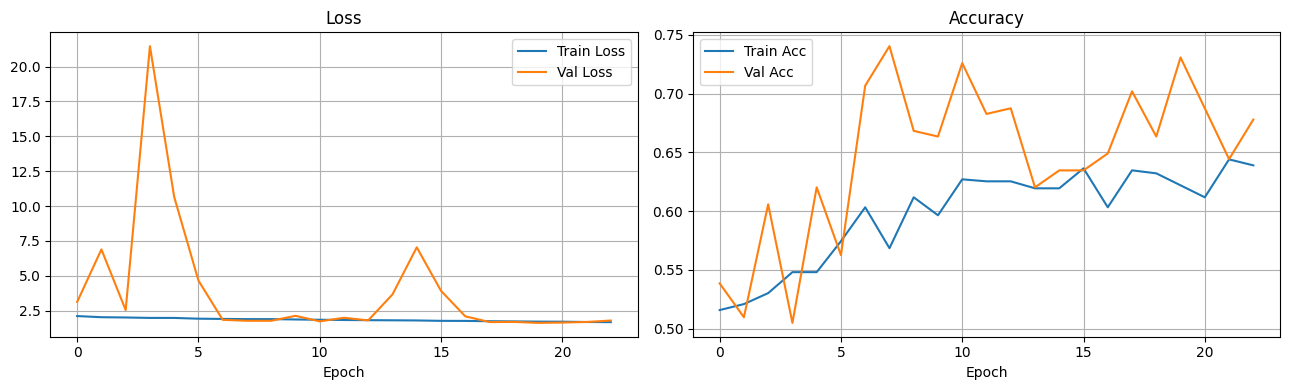

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 11. Validation Evaluation (Balanced Accuracy)

Note: because training used soft MixUp/CutMix labels, we evaluate on the **original hard val labels**.

In [13]:
# Load best saved model for evaluation
best_model = keras.models.load_model('best_model.keras')

val_probs = best_model.predict(val_ds, verbose=0)
val_preds = np.argmax(val_probs, axis=1)

bal_acc = balanced_accuracy_score(y_val, val_preds)
print(f'Validation Balanced Accuracy: {bal_acc:.4f}')

for cls, name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    mask    = y_val == cls
    cls_acc = (val_preds[mask] == y_val[mask]).mean()
    print(f'  Class {cls} ({name:15s}): {cls_acc:.4f}')

TypeError: <class 'keras.src.optimizers.adamw.AdamW'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.optimizers', 'class_name': 'AdamW', 'config': {'name': 'adamw', 'learning_rate': {'module': None, 'class_name': 'WarmupCosineDecay', 'config': {'init_lr': 0.001, 'total_steps': 2160, 'warmup_steps': 180}, 'registered_name': 'WarmupCosineDecay'}, 'weight_decay': 0.0001, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}.

Exception encountered: Could not locate class 'WarmupCosineDecay'. Make sure custom classes and functions are decorated with `@keras.saving

## 12. Test-Time Augmentation (TTA)

**Why TTA?**  
Run the model multiple times on augmented versions of each test image, then average the probability outputs. Reduces variance from random image variation — essentially a free ensemble at inference time. Typically adds +1–3% balanced accuracy.

In [ ]:
@tf.function
def tta_augment(image):
    """Light augmentation used during TTA inference."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    # Small random crop
    pad = int(IMG_HEIGHT * 0.05)
    image = tf.image.pad_to_bounding_box(
        image, pad, pad, IMG_HEIGHT + 2*pad, IMG_WIDTH + 2*pad)
    image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    return tf.clip_by_value(image, 0.0, 1.0)


def predict_tta(model, X, steps=TTA_STEPS, batch_size=BATCH_SIZE):
    """
    Average predictions over `steps` augmented passes.
    Pass 0 is always the clean (unaugmented) image.
    """
    probs_sum = np.zeros((len(X), 2), dtype=np.float32)

    for step in range(steps):
        if step == 0:
            # First pass: clean images
            ds = (tf.data.Dataset
                  .from_tensor_slices(X)
                  .batch(batch_size)
                  .prefetch(AUTOTUNE))
        else:
            # Subsequent passes: augmented
            ds = (tf.data.Dataset
                  .from_tensor_slices(X)
                  .map(tta_augment, num_parallel_calls=AUTOTUNE)
                  .batch(batch_size)
                  .prefetch(AUTOTUNE))
        probs_sum += model.predict(ds, verbose=0)

    return probs_sum / steps


# ── Evaluate TTA on validation set ───────────────────────────
print(f'Running TTA ({TTA_STEPS} steps) on validation set …')
val_probs_tta = predict_tta(best_model, X_val)
val_preds_tta = np.argmax(val_probs_tta, axis=1)
bal_acc_tta   = balanced_accuracy_score(y_val, val_preds_tta)
print(f'Val Balanced Accuracy (no TTA): {bal_acc:.4f}')
print(f'Val Balanced Accuracy (TTA):    {bal_acc_tta:.4f}')

## 13. Test Set Prediction with TTA

In [ ]:
print(f'Running TTA ({TTA_STEPS} steps) on test set …')
test_probs_tta = predict_tta(best_model, X_test)
test_preds     = np.argmax(test_probs_tta, axis=1)

print('Test predictions shape:', test_preds.shape)
print('Predicted label distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Label {u}: {c}')

# Generating Final Submissions


In [ ]:
test_ids = TEST_LABEL.index.tolist()

submission = pd.DataFrame({
    'id':    test_ids,
    'label': test_preds
})
submission = submission.set_index('id')

submission.to_csv('submission6.csv')
print('submission.csv saved!')
print(submission.head(10))

## ✅ Verify submission format

In [ ]:
sub_check = pd.read_csv('submission.csv', index_col='id')
print('Submission shape:', sub_check.shape)
print('Unique labels:', sorted(sub_check['label'].unique()))
assert set(sub_check['label'].unique()).issubset({0, 1}), \
    'ERROR: labels must be 0 or 1!'
assert len(sub_check) == len(TEST_LABEL), \
    f'ERROR: expected {len(TEST_LABEL)} rows, got {len(sub_check)}'
print('✅ Submission looks correct – ready to upload to Kaggle!')